In [516]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [517]:
df1 = pd.read_csv("/content/dgit recognizer train.csv")

In [518]:
df1.shape

(42000, 785)

In [519]:
df1.sample(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
32581,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29216,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2312,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3329,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2543,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [520]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [521]:
df1.isnull().sum().sum()

np.int64(0)

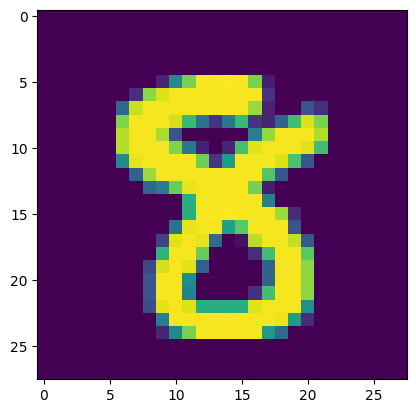

In [522]:
plt.imshow(df1.iloc[3185,1:].values.reshape(28,28))

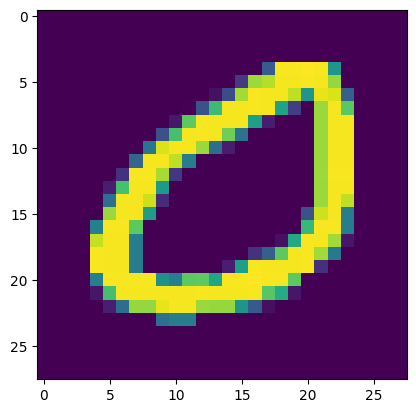

In [523]:
plt.imshow(df1.iloc[3299,1:].values.reshape(28,28))

In [524]:
X = df1.drop('label', axis=1)
y = df1["label"]

In [525]:
X_train, X_test,  y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [526]:
X_train.shape

(33600, 784)

In [527]:
X_test.shape

(8400, 784)

In [528]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [529]:
y_pred = knn.predict(X_test)
print(round(accuracy_score(y_test, y_pred),2))
print(classification_report(y_test, y_pred))

0.96
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       816
           1       0.94      1.00      0.97       909
           2       0.99      0.94      0.96       846
           3       0.96      0.96      0.96       937
           4       0.98      0.97      0.98       839
           5       0.96      0.95      0.96       702
           6       0.97      0.99      0.98       785
           7       0.96      0.96      0.96       893
           8       0.99      0.93      0.96       835
           9       0.94      0.95      0.95       838

    accuracy                           0.96      8400
   macro avg       0.97      0.96      0.96      8400
weighted avg       0.97      0.96      0.96      8400



In [530]:
for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    print(f"K={k}, Accuracy={round(accuracy_score(y_test, knn.predict(X_test)),3)}")

K=1, Accuracy=0.969
K=2, Accuracy=0.962
K=3, Accuracy=0.967
K=4, Accuracy=0.964
K=5, Accuracy=0.965
K=6, Accuracy=0.964
K=7, Accuracy=0.963
K=8, Accuracy=0.963
K=9, Accuracy=0.961
K=10, Accuracy=0.962


Principle compond  analysis (PCA)

In [531]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [532]:
pca = PCA(n_components=None)

In [533]:
X_train = pca.fit_transform(X_train)
X_test = pca.fit_transform(X_test)

In [534]:
X_train.shape

(33600, 784)

In [535]:
X_test.shape

(8400, 784)

In [536]:
pca1 = PCA(n_components=100)

In [537]:
X_train_trf = pca1.fit_transform(X_train)
X_test_trf = pca1.fit_transform(X_test)

In [538]:
X_train_trf.shape

(33600, 100)

In [539]:
X_test_trf.shape

(8400, 100)

In [540]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf, y_train)

KNeighborsClassifier()

In [541]:
y_pred1 = knn.predict(X_test_trf)
print(round(accuracy_score(y_test, y_pred1),3))
print(classification_report(y_test, y_pred1))

0.642
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       816
           1       0.85      0.80      0.82       909
           2       0.82      0.74      0.78       846
           3       0.71      0.59      0.64       937
           4       0.36      0.31      0.33       839
           5       0.51      0.51      0.51       702
           6       0.85      0.81      0.83       785
           7       0.84      0.70      0.76       893
           8       0.35      0.49      0.41       835
           9       0.48      0.60      0.53       838

    accuracy                           0.64      8400
   macro avg       0.66      0.64      0.64      8400
weighted avg       0.66      0.64      0.65      8400



In [542]:
pca2 = PCA(n_components=200)

In [543]:
X_train_trf1 = pca2.fit_transform(X_train)
X_test_trf1 = pca2.fit_transform(X_test)

In [544]:
X_train_trf1.shape

(33600, 200)

In [545]:
knn = KNeighborsClassifier()
knn.fit(X_train_trf1, y_train)

KNeighborsClassifier()

In [546]:
y_pred2 = knn.predict(X_test_trf1)
print(round(accuracy_score(y_test, y_pred2),3))
print(classification_report(y_test, y_pred2))

0.644
              precision    recall  f1-score   support

           0       0.76      0.88      0.82       816
           1       0.78      0.88      0.83       909
           2       0.85      0.67      0.75       846
           3       0.73      0.63      0.67       937
           4       0.37      0.35      0.36       839
           5       0.49      0.48      0.48       702
           6       0.87      0.77      0.82       785
           7       0.84      0.69      0.76       893
           8       0.39      0.42      0.41       835
           9       0.46      0.63      0.53       838

    accuracy                           0.64      8400
   macro avg       0.65      0.64      0.64      8400
weighted avg       0.66      0.64      0.65      8400



In [547]:
# transform to 2d coordinate system

pca1 = PCA(n_components=2)
X_train_trf = pca1.fit_transform(X_train)
X_test_trf = pca1.fit_transform(X_test)

In [548]:
X_train_trf

array([[-2.71863253, -0.48982409],
       [-0.67698015, -6.75362491],
       [-3.03323281,  6.50981624],
       ...,
       [ 2.14883643,  0.78079444],
       [ 1.05957006,  0.94767312],
       [17.70258446,  1.96188185]])

In [549]:
X_train_trf.shape

(33600, 2)

In [550]:
import plotly.express as px

In [551]:
y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],y= X_train_trf[:,1],color = y_train_trf,color_discrete_sequence=px.colors.qualitative.G10)
fig.show()

In [552]:
# tranforming in 3D

pca1 = PCA(n_components=3)
X_train_trf = pca1.fit_transform(X_train)
X_test_trf = pca1.fit_transform(X_test)

In [553]:
X_train_trf

array([[-2.71863253, -0.48982409,  1.1354966 ],
       [-0.67698015, -6.75362491, -2.33590139],
       [-3.03323281,  6.50981624,  7.49182983],
       ...,
       [ 2.14883643,  0.78079444, -0.74738774],
       [ 1.05957006,  0.94767312,  3.94973114],
       [17.70258446,  1.96188185, -4.94352837]])

In [554]:
X_train_trf.shape

(33600, 3)

In [555]:
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df1,x=X_train_trf[:,0],y= X_train_trf[:,1],z=X_train_trf[:,2],color = y_train_trf)
fig.update_layout(margin=dict(l=20, r=20, t=20, b=20))
fig.show()

In [556]:
pca1.explained_variance_
# eigen value

array([40.87278367, 28.96628019, 27.04280036])

In [557]:
pca1.components_.shape
# eigen vector

(3, 784)

In [558]:
pca1.explained_variance_ratio_

array([0.06054506, 0.0429079 , 0.04005864])

In [559]:
pca1.explained_variance_ratio_.shape

(3,)

In [560]:
pca = PCA(n_components=None)
X_train_trf3 = pca.fit_transform(X_train)
X_test_trf3 = pca.fit_transform(X_test)

In [561]:
pca.explained_variance_

array([4.08727837e+01, 2.89662802e+01, 2.70428004e+01, 2.06867883e+01,
       1.80302201e+01, 1.55676934e+01, 1.37180098e+01, 1.28553924e+01,
       1.13029032e+01, 1.01403309e+01, 9.76923285e+00, 8.82905522e+00,
       8.06129222e+00, 7.88488106e+00, 7.60700430e+00, 7.23557782e+00,
       6.82238306e+00, 6.81508304e+00, 6.48782951e+00, 6.39913136e+00,
       6.13346182e+00, 5.76252759e+00, 5.57609776e+00, 5.44995438e+00,
       5.31119167e+00, 5.15527872e+00, 5.01762185e+00, 4.81398782e+00,
       4.73591504e+00, 4.55311172e+00, 4.51920555e+00, 4.40149789e+00,
       4.31668874e+00, 4.12026063e+00, 4.06446124e+00, 4.00045930e+00,
       3.97224384e+00, 3.87458959e+00, 3.79601430e+00, 3.64675229e+00,
       3.56504324e+00, 3.53165189e+00, 3.45701947e+00, 3.40722064e+00,
       3.28821058e+00, 3.22294318e+00, 3.16606194e+00, 3.16025957e+00,
       3.10742422e+00, 3.07025285e+00, 3.01596603e+00, 2.99267737e+00,
       2.94736841e+00, 2.88525956e+00, 2.83528784e+00, 2.80254246e+00,
      

In [562]:
pca.explained_variance_.shape

(784,)

In [563]:
pca.components_

array([[ 1.00000000e+00, -2.71689802e-16, -2.63138480e-16, ...,
         2.11049931e-17,  3.84350720e-17, -5.23637170e-17],
       [ 2.71689802e-16,  1.00000000e+00, -9.15933995e-15, ...,
         6.85802947e-17,  3.30688889e-17, -1.30972595e-17],
       [ 2.63138480e-16,  9.46465128e-15,  1.00000000e+00, ...,
         1.77467598e-16,  3.93541502e-17, -8.03850830e-17],
       ...,
       [-0.00000000e+00,  7.75544526e-17,  6.84035269e-17, ...,
         1.58695808e-01,  3.34354779e-01, -6.54136393e-02],
       [-1.29449650e-16,  1.11022302e-16, -1.38777878e-17, ...,
         1.76581879e-01, -1.36368123e-01, -4.59598879e-01],
       [-3.67604351e-16,  4.44089210e-16, -4.99600361e-16, ...,
        -4.76999076e-03,  1.52576752e-01,  1.93991089e-02]])

In [564]:
pca.components_.shape

(784, 784)

In [565]:
pca.explained_variance_ratio_

array([6.05450635e-02, 4.29078990e-02, 4.00586385e-02, 3.06434453e-02,
       2.67082572e-02, 2.30605039e-02, 2.03205581e-02, 1.90427586e-02,
       1.67430484e-02, 1.50209240e-02, 1.44712146e-02, 1.30785247e-02,
       1.19412334e-02, 1.16799146e-02, 1.12682944e-02, 1.07180984e-02,
       1.01060309e-02, 1.00952174e-02, 9.61045504e-03, 9.47906601e-03,
       9.08552837e-03, 8.53606160e-03, 8.25990213e-03, 8.07304529e-03,
       7.86749539e-03, 7.63654074e-03, 7.43262890e-03, 7.13098479e-03,
       7.01533517e-03, 6.74454768e-03, 6.69432230e-03, 6.51996133e-03,
       6.39433310e-03, 6.10336315e-03, 6.02070722e-03, 5.92590082e-03,
       5.88410511e-03, 5.73944937e-03, 5.62305540e-03, 5.40195282e-03,
       5.28091679e-03, 5.23145401e-03, 5.12090062e-03, 5.04713335e-03,
       4.87084315e-03, 4.77416222e-03, 4.68990375e-03, 4.68130866e-03,
       4.60304339e-03, 4.54798125e-03, 4.46756591e-03, 4.43306830e-03,
       4.36595190e-03, 4.27394974e-03, 4.19992637e-03, 4.15142048e-03,
      

In [566]:
pca.explained_variance_ratio_.shape

(784,)

In [567]:
np.cumsum(pca.explained_variance_ratio_)

array([0.06054506, 0.10345296, 0.1435116 , 0.17415505, 0.2008633 ,
       0.22392381, 0.24424437, 0.26328712, 0.28003017, 0.2950511 ,
       0.30952231, 0.32260084, 0.33454207, 0.34622198, 0.35749028,
       0.36820838, 0.37831441, 0.38840962, 0.39802008, 0.40749915,
       0.41658467, 0.42512074, 0.43338064, 0.44145368, 0.44932118,
       0.45695772, 0.46439035, 0.47152133, 0.47853667, 0.48528122,
       0.49197554, 0.4984955 , 0.50488983, 0.5109932 , 0.5170139 ,
       0.5229398 , 0.52882391, 0.53456336, 0.54018641, 0.54558837,
       0.55086928, 0.55610074, 0.56122164, 0.56626877, 0.57113961,
       0.57591378, 0.58060368, 0.58528499, 0.58988803, 0.59443601,
       0.59890358, 0.60333665, 0.6077026 , 0.61197655, 0.61617648,
       0.6203279 , 0.6243674 , 0.62836904, 0.632244  , 0.63608538,
       0.63988348, 0.64363517, 0.64732886, 0.65099829, 0.65461534,
       0.65818137, 0.66169008, 0.66515602, 0.66856668, 0.67192998,
       0.67525401, 0.67855196, 0.68178585, 0.68499317, 0.68817

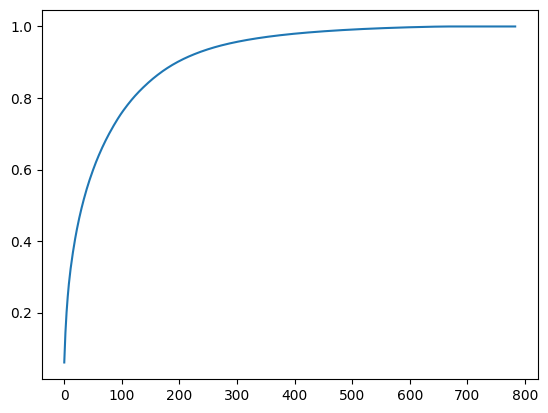

In [568]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))